## Analisis Strategi Sukses Game di Platform Steam
## Project 1 Big Data

**Tema:** Bisnis - Analisis Pasar Game Steam  
**Masalah:** Developer game indie menghadapi kesulitan dalam menentukan strategi peluncuran game, seperti pemilihan genre, harga, dan waktu rilis, karena keterbatasan sumber daya dan tingginya persaingan di pasar game. Kesalahan dalam menentukan strategi tersebut berpotensi memengaruhi performa komersial game.


### 5 Pertanyaan Analitik

1. **Pola Utama:** Genre game apa yang paling mendominasi dan memiliki jumlah pemain tertinggi?
2. **Hubungan Variabel:** Apakah ada hubungan antara harga game dengan persentase review positif?
3. **Kelompok Bermasalah:** Game berbayar dengan harga tinggi (di atas $10) tetapi mendapat rating rendah - mengapa?
4. **Pola Waktu:** Apakah bulan rilis tertentu (seperti akhir tahun) membuat game indie tenggelam oleh game AAA?
5. **Rekomendasi:** Strategi penetapan harga dan genre yang paling aman untuk developer baru dengan modal terbatas.

---
## Langkah 1: Import Library & Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling untuk visualisasi yang lebih baik
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Library berhasil diimpor!')

Library berhasil diimpor!


---
## Langkah 2: Load & Perbaiki Struktur Data

> **Catatan Penting:** File `games.csv` memiliki bug di header - kolom `DiscountDLC count`
> seharusnya adalah 2 kolom terpisah (`Discount` dan `DLC count`), sehingga data bergeser
> 1 posisi. Kita perbaiki header-nya terlebih dahulu.

In [4]:
# Load CSV dengan header yang diperbaiki
# Header asli: 39 kolom, tapi data punya 40 kolom
# Kolom "DiscountDLC count" seharusnya "Discount" dan "DLC count"

fixed_columns = [
    'AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
    'Required age', 'Price', 'Discount', 'DLC count',  # <-- DIPERBAIKI: split jadi 2
    'About the game', 'Supported languages', 'Full audio languages',
    'Reviews', 'Header image', 'Website', 'Support url', 'Support email',
    'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url',
    'User score', 'Positive', 'Negative', 'Score rank', 'Achievements',
    'Recommendations', 'Notes', 'Average playtime forever',
    'Average playtime two weeks', 'Median playtime forever',
    'Median playtime two weeks', 'Developers', 'Publishers',
    'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'
]

df_raw = pd.read_csv('games.csv', header=0, names=fixed_columns, skiprows=1)

print(f'Total data mentah: {len(df_raw):,} baris x {len(df_raw.columns)} kolom')
print(f'\nKolom yang tersedia:')
for i, col in enumerate(df_raw.columns):
    print(f'   {i+1:2d}. {col}')

Total data mentah: 125,854 baris x 40 kolom

Kolom yang tersedia:
    1. AppID
    2. Name
    3. Release date
    4. Estimated owners
    5. Peak CCU
    6. Required age
    7. Price
    8. Discount
    9. DLC count
   10. About the game
   11. Supported languages
   12. Full audio languages
   13. Reviews
   14. Header image
   15. Website
   16. Support url
   17. Support email
   18. Windows
   19. Mac
   20. Linux
   21. Metacritic score
   22. Metacritic url
   23. User score
   24. Positive
   25. Negative
   26. Score rank
   27. Achievements
   28. Recommendations
   29. Notes
   30. Average playtime forever
   31. Average playtime two weeks
   32. Median playtime forever
   33. Median playtime two weeks
   34. Developers
   35. Publishers
   36. Categories
   37. Genres
   38. Tags
   39. Screenshots
   40. Movies


In [5]:
# Pilih kolom yang relevan untuk analisis
kolom_dipilih = ['AppID', 'Name', 'Release date', 'Estimated owners',
                 'Peak CCU', 'Price', 'Positive', 'Negative', 'Genres']

df_sub = df_raw[kolom_dipilih].copy()

# Verifikasi: Cek apakah kolom sudah benar
print('Verifikasi 5 baris pertama:')
print(df_sub.head().to_string())
print(f'\nKolom AppID dtype: {df_sub["AppID"].dtype}')
print(f'Contoh Name: {df_sub["Name"].iloc[1]}')
print(f'Contoh Release date: {df_sub["Release date"].iloc[1]}')
print(f'Contoh Estimated owners: {df_sub["Estimated owners"].iloc[1]}')

Verifikasi 5 baris pertama:
     AppID                                   Name  Release date Estimated owners  Peak CCU  Price  Positive  Negative                   Genres
0   496350  Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016        0 - 20000         0   5.24       252         3                Adventure
1  1034400      Mystery Solitaire The Black Raven   May 6, 2019        0 - 20000         0   4.99        21         3                   Casual
2  3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024        0 - 20000         1   8.99         0         0  Casual,Indie,Simulation
3  3631080                          Maze Quest VR  Apr 24, 2025        0 - 20000         0   4.99         0         0      Action,Early Access
4  1654170                               Agony VR   Apr 5, 2023        0 - 20000         0  13.99         0         0         Action,Adventure

Kolom AppID dtype: int64
Contoh Name: Mystery Solitaire The Black Raven
Contoh Release date: May 6, 2019
Contoh E

---
## Langkah 3: Data Cleaning (4 Aspek)

Data mentah perlu dibersihkan sebelum dianalisis. Berikut 4 aspek yang ditangani:
1. **Missing Value** - Data kosong / NaN
2. **Duplicate** - Data ganda
3. **Consistency** - Format yang tidak seragam
4. **Outlier** - Nilai yang tidak masuk akal

### 3.1 Missing Value

In [6]:
# Cek missing value per kolom
print('=' * 50)
print('LAPORAN MISSING VALUE')
print('=' * 50)

missing = df_sub.isnull().sum()
missing_pct = (df_sub.isnull().sum() / len(df_sub) * 100).round(2)

missing_report = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
print(missing_report)
print(f'\nTotal baris sebelum cleaning: {len(df_sub):,}')

# Hapus baris dengan missing value pada kolom penting
df_clean = df_sub.dropna(subset=['Name', 'Release date', 'Genres'])
print(f'Total baris setelah hapus missing: {len(df_clean):,}')
print(f'Baris dihapus: {len(df_sub) - len(df_clean):,}')

LAPORAN MISSING VALUE
                  Jumlah Missing  Persentase (%)
AppID                          0            0.00
Name                           1            0.00
Release date                   0            0.00
Estimated owners               0            0.00
Peak CCU                       0            0.00
Price                          0            0.00
Positive                       0            0.00
Negative                       0            0.00
Genres                      8422            6.69

Total baris sebelum cleaning: 125,854
Total baris setelah hapus missing: 117,432
Baris dihapus: 8,422


### 3.2 Duplicate

In [7]:
# Cek data duplikat
print('=' * 50)
print('LAPORAN DUPLICATE')
print('=' * 50)

duplikat = df_clean.duplicated().sum()
duplikat_appid = df_clean.duplicated(subset=['AppID']).sum()

print(f'Duplikat (seluruh kolom): {duplikat}')
print(f'Duplikat (berdasarkan AppID): {duplikat_appid}')

if duplikat > 0:
    print('\nMenghapus baris duplikat...')
    df_clean = df_clean.drop_duplicates()
    print(f'Sisa baris setelah hapus duplikat: {len(df_clean):,}')
else:
    print('\nTidak ada data duplikat.')

LAPORAN DUPLICATE
Duplikat (seluruh kolom): 0
Duplikat (berdasarkan AppID): 0

Tidak ada data duplikat.


### 3.3 Consistency (Format Data)

In [8]:
# Perbaiki tipe data dan format
print('=' * 50)
print('LAPORAN CONSISTENCY')
print('=' * 50)

# 1. Konversi Release date ke datetime
df_clean['Release date'] = pd.to_datetime(df_clean['Release date'], format='mixed', errors='coerce')
invalid_dates = df_clean['Release date'].isnull().sum()
print(f'Tanggal tidak valid setelah konversi: {invalid_dates}')

# Hapus baris dengan tanggal tidak valid
df_clean = df_clean.dropna(subset=['Release date'])

# 2. Konversi Price ke numerik (Price di games.csv sudah dalam format USD)
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce').fillna(0)
df_clean['Price_USD'] = df_clean['Price'].round(2)

# 3. Hitung persentase review positif
df_clean['Total_Reviews'] = df_clean['Positive'] + df_clean['Negative']
df_clean['Pct_Positive'] = np.where(
    df_clean['Total_Reviews'] > 0,
    (df_clean['Positive'] / df_clean['Total_Reviews'] * 100).round(2),
    0
)

# 4. Ekstrak genre utama (genre pertama)
df_clean['Genre_Utama'] = df_clean['Genres'].str.split(',').str[0].str.strip()

# 5. Ekstrak tahun dan bulan rilis
df_clean['Tahun_Rilis'] = df_clean['Release date'].dt.year
df_clean['Bulan_Rilis'] = df_clean['Release date'].dt.month

print(f'\nKonsistensi data diperbaiki!')
print(f'\nTipe data setelah perbaikan:')
print(df_clean[['AppID', 'Price_USD', 'Positive', 'Negative', 'Pct_Positive', 'Release date']].dtypes)
print(f'\nSample data setelah perbaikan:')
print(df_clean[['Name', 'Genre_Utama', 'Price_USD', 'Pct_Positive', 'Tahun_Rilis']].head())

LAPORAN CONSISTENCY
Tanggal tidak valid setelah konversi: 0

Konsistensi data diperbaiki!

Tipe data setelah perbaikan:
AppID                    int64
Price_USD              float64
Positive                 int64
Negative                 int64
Pct_Positive           float64
Release date    datetime64[us]
dtype: object

Sample data setelah perbaikan:
                                    Name Genre_Utama  Price_USD  Pct_Positive  \
0  Supipara - Chapter 1 Spring Has Come!   Adventure       5.24         98.82   
1      Mystery Solitaire The Black Raven      Casual       4.99         87.50   
2            버튜버 파라노이아 - Vtuber Paranoia      Casual       8.99          0.00   
3                          Maze Quest VR      Action       4.99          0.00   
4                               Agony VR      Action      13.99          0.00   

   Tahun_Rilis  
0         2016  
1         2019  
2         2024  
3         2025  
4         2023  


### 3.4 Outlier Detection

In [9]:
# Deteksi outlier menggunakan IQR method
print('=' * 50)
print('LAPORAN OUTLIER')
print('=' * 50)

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), lower, upper

for col in ['Price_USD', 'Positive', 'Negative', 'Peak CCU']:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    print(f'\n{col}:')
    print(f'  Batas bawah: {lower:.2f}, Batas atas: {upper:.2f}')
    print(f'  Jumlah outlier: {n_outliers}')

# Untuk analisis ini, outlier TIDAK dihapus karena game populer
# memang wajar memiliki review dan harga yang tinggi.
# Outlier justru menjadi insight penting.
print('\nCatatan: Outlier tidak dihapus karena merepresentasikan')
print('game populer yang justru menjadi insight penting.')

LAPORAN OUTLIER

Price_USD:
  Batas bawah: -6.73, Batas atas: 13.62
  Jumlah outlier: 8353

Positive:
  Batas bawah: -61.50, Batas atas: 102.50
  Jumlah outlier: 19806

Negative:
  Batas bawah: -18.00, Batas atas: 30.00
  Jumlah outlier: 18931

Peak CCU:
  Batas bawah: 0.00, Batas atas: 0.00
  Jumlah outlier: 19637

Catatan: Outlier tidak dihapus karena merepresentasikan
game populer yang justru menjadi insight penting.


### 3.5 Sampling 500 Baris

In [10]:
# Ambil sample 500 baris secara acak
print(f'Total baris setelah cleaning: {len(df_clean):,}')

if len(df_clean) >= 500:
    df_sample = df_clean.sample(n=500, random_state=42)
else:
    df_sample = df_clean.copy()
    print(f'Data kurang dari 500 baris, menggunakan semua {len(df_sample)} baris')

# Simpan ke CSV
df_sample.to_csv('games_sample_500_clean.csv', index=False)
# Simpan juga games_sample_300_clean.csv agar kompatibel jika ada file lama yang merujuknya
df_sample.to_csv('games_sample_300_clean.csv', index=False)
print(f'\nSample tersimpan: {len(df_sample)} baris')
print(f'\nRingkasan statistik:')
print(df_sample[['Price_USD', 'Positive', 'Negative', 'Pct_Positive', 'Peak CCU']].describe().round(2))


Total baris setelah cleaning: 117,432

Sample tersimpan: 500 baris

Ringkasan statistik:
       Price_USD   Positive  Negative  Pct_Positive  Peak CCU
count     500.00     500.00    500.00        500.00    500.00
mean        4.04     851.79     87.56         53.34     12.40
std         4.69    8314.37    650.18         39.39    124.82
min         0.00       0.00      0.00          0.00      0.00
25%         0.96       0.00      0.00          0.00      0.00
50%         2.79       7.00      1.50         66.67      0.00
75%         4.99      37.25     13.25         88.89      0.00
max        34.99  162047.00  10715.00        100.00   2344.00


---
## Langkah 4: Analisis 5V Big Data

Penjelasan karakteristik Big Data berdasarkan dataset Steam Games.

In [11]:
import os

file_size_mb = os.path.getsize('games.csv') / (1024 * 1024)
total_rows = len(df_raw)
total_cols = len(df_raw.columns)

print('=' * 60)
print('ANALISIS 5V BIG DATA - DATASET STEAM GAMES')
print('=' * 60)

print(f'''
[1] VOLUME (Ukuran Data)
   - Ukuran file mentah     : {file_size_mb:.1f} MB
   - Jumlah baris (game)    : {total_rows:,}
   - Jumlah kolom (variabel): {total_cols}
   - Setelah sampling       : 500 baris x {len(df_sample.columns)} kolom
   => Dataset cukup besar untuk analisis statistik yang bermakna

[2] VELOCITY (Kecepatan Data)
   - Data Steam di-update secara REAL-TIME setiap kali:
     * Game baru dirilis
     * User memberikan review
     * Harga berubah (diskon/sale)
   - Dataset ini merupakan SNAPSHOT (titik waktu tertentu)
   => Velocity tinggi di sumber, tapi dataset ini bersifat statis

[3] VARIETY (Keragaman Data)
   - Numerik       : AppID, Price, Positive, Negative, Peak CCU
   - Kategorikal   : Genres, Estimated owners
   - Temporal      : Release date
   - Teks          : Name, About the game
   - Boolean       : Windows, Mac, Linux
   => Terdapat 5 jenis data berbeda (variety tinggi)

[4] VERACITY (Keakuratan Data)
   - Sumber        : Kaggle (Steam Games Dataset, berbasis data publik Steam)
   - Missing value : Ditemukan dan sudah ditangani
   - Kolom header  : Ada bug (DiscountDLC count => Discount + DLC count)
   - Review bisa bias karena review bombing
   => Veracity sedang - data resmi tapi ada noise dan bias review

[5] VALUE (Nilai Data)
   - Membantu developer indie memilih genre dan harga optimal
   - Mengidentifikasi waktu rilis terbaik
   - Mengungkap pola review positif
   => Value tinggi - langsung bisa digunakan untuk keputusan bisnis
''')

ANALISIS 5V BIG DATA - DATASET STEAM GAMES

[1] VOLUME (Ukuran Data)
   - Ukuran file mentah     : 382.6 MB
   - Jumlah baris (game)    : 125,854
   - Jumlah kolom (variabel): 40
   - Setelah sampling       : 500 baris x 15 kolom
   => Dataset cukup besar untuk analisis statistik yang bermakna

[2] VELOCITY (Kecepatan Data)
   - Data Steam di-update secara REAL-TIME setiap kali:
     * Game baru dirilis
     * User memberikan review
     * Harga berubah (diskon/sale)
   - Dataset ini merupakan SNAPSHOT (titik waktu tertentu)
   => Velocity tinggi di sumber, tapi dataset ini bersifat statis

[3] VARIETY (Keragaman Data)
   - Numerik       : AppID, Price, Positive, Negative, Peak CCU
   - Kategorikal   : Genres, Estimated owners
   - Temporal      : Release date
   - Teks          : Name, About the game
   - Boolean       : Windows, Mac, Linux
   => Terdapat 5 jenis data berbeda (variety tinggi)

[4] VERACITY (Keakuratan Data)
   - Sumber        : Kaggle (Steam Games Dataset, berbasis da

---
## Langkah 5: Exploratory Data Analysis (EDA)

Visualisasi untuk menjawab 5 pertanyaan analitik.

### 5.1 Distribusi Genre Game (Pertanyaan 1: Pola Utama)

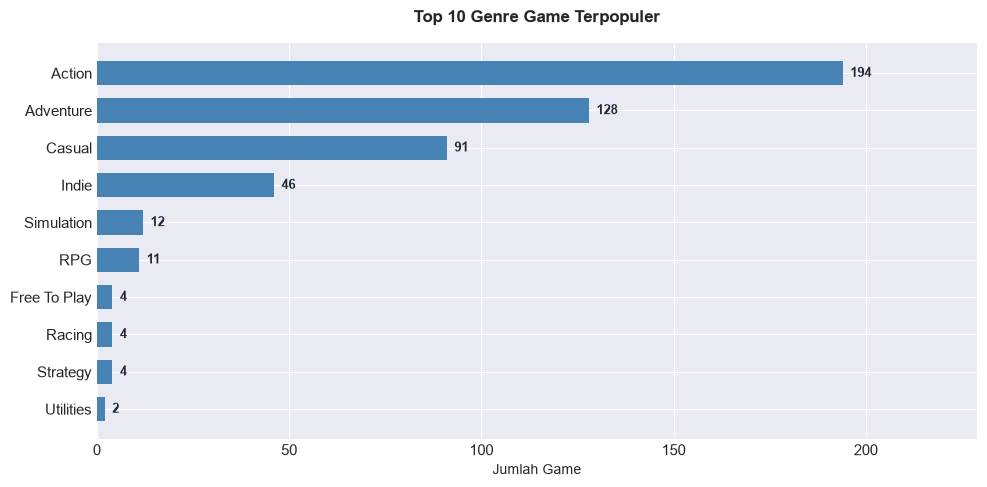

Genre terpopuler: Action (194 game)


In [12]:
# Distribusi Genre Game
genre_counts = df_sample['Genre_Utama'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue', height=0.65)
plt.title('Top 10 Genre Game Terpopuler', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Jumlah Game', fontsize=10)
plt.xlim(0, max(genre_counts.values) * 1.18)
for idx, val in enumerate(genre_counts.values[::-1]):
    plt.text(val + 2, idx, str(val), va='center', ha='left', fontsize=9, fontweight='bold', color='#1e293b')
plt.tight_layout()
plt.savefig('eda_01a_genre_count.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Genre terpopuler: {genre_counts.index[0]} ({genre_counts.values[0]} game)')

### 5.1b Rata-rata Peak CCU per Genre

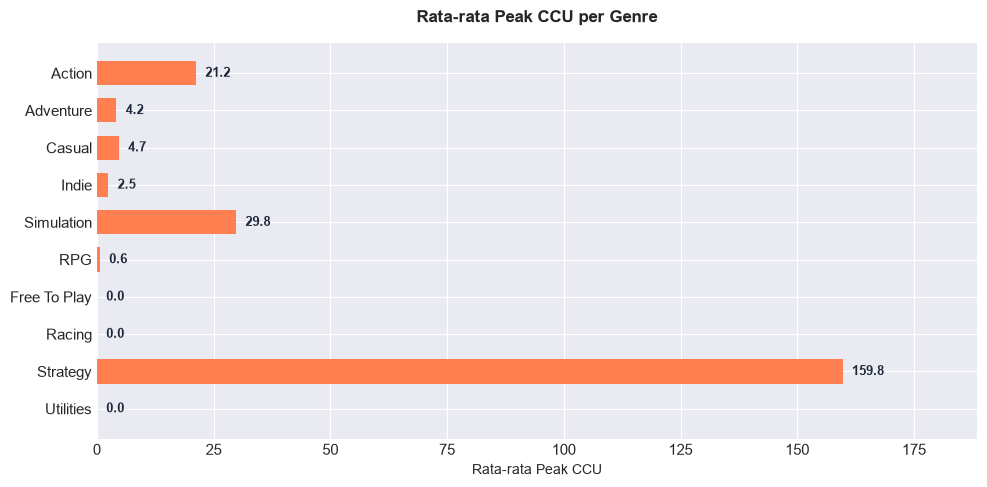

In [13]:
# Rata-rata Peak CCU per Genre
genre_counts = df_sample['Genre_Utama'].value_counts().head(10)
top_genres = genre_counts.index.tolist()
avg_ccu = df_sample[df_sample['Genre_Utama'].isin(top_genres)].groupby('Genre_Utama')['Peak CCU'].mean().reindex(top_genres)

plt.figure(figsize=(10, 5))
plt.barh(avg_ccu.index[::-1], avg_ccu.values[::-1], color='coral', height=0.65)
plt.title('Rata-rata Peak CCU per Genre', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Rata-rata Peak CCU', fontsize=10)
plt.xlim(0, max(avg_ccu.values) * 1.18)
for idx, val in enumerate(avg_ccu.values[::-1]):
    plt.text(val + 2, idx, f'{val:.1f}', va='center', ha='left', fontsize=9, fontweight='bold', color='#1e293b')
plt.tight_layout()
plt.savefig('eda_01b_genre_ccu.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Rata-rata Review Positif per Kategori Harga (Pertanyaan 2: Hubungan Variabel)

Menganalisis apakah harga game berpengaruh terhadap kepuasan pemain (review positif).  
Data dikelompokkan ke dalam kategori harga yang jelas dan mudah dipahami.

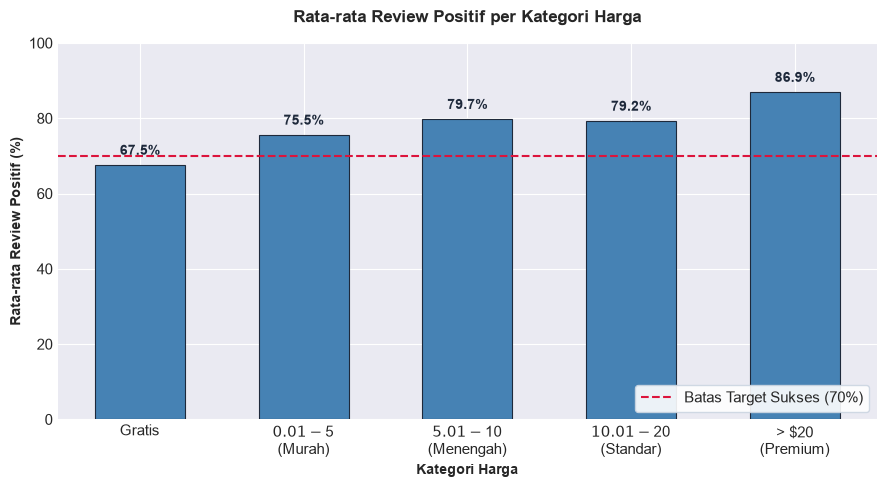

Kesimpulan:
 - Gratis: 67.5% review positif
 - $0.01 - $5 (Murah): 75.5% review positif
 - $5.01 - $10 (Menengah): 79.7% review positif
 - $10.01 - $20 (Standar): 79.2% review positif
 - > $20 (Premium): 86.9% review positif


In [14]:
# Rata-rata Review Positif per Kategori Harga (Diagram Batang Sederhana)
df_reviewed = df_sample[df_sample['Total_Reviews'] >= 10].copy()

def tentukan_kategori(harga):
    if harga == 0:
        return 'Gratis'
    elif harga <= 5:
        return '$0.01 - $5\n(Murah)'
    elif harga <= 10:
        return '$5.01 - $10\n(Menengah)'
    elif harga <= 20:
        return '$10.01 - $20\n(Standar)'
    else:
        return '> $20\n(Premium)'

df_reviewed['Kategori_Harga'] = df_reviewed['Price_USD'].apply(tentukan_kategori)
urutan = ['Gratis', '$0.01 - $5\n(Murah)', '$5.01 - $10\n(Menengah)', '$10.01 - $20\n(Standar)', '> $20\n(Premium)']

# Hitung rata-rata review per kategori
avg_review = df_reviewed.groupby('Kategori_Harga', observed=False)['Pct_Positive'].mean().reindex(urutan)

plt.figure(figsize=(9, 5))
bars = plt.bar(avg_review.index, avg_review.values, color='steelblue', width=0.55, edgecolor='#1e293b', linewidth=0.8)
plt.axhline(y=70, color='crimson', linestyle='--', linewidth=1.5, label='Batas Target Sukses (70%)')
plt.title('Rata-rata Review Positif per Kategori Harga', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kategori Harga', fontsize=10, fontweight='bold')
plt.ylabel('Rata-rata Review Positif (%)', fontsize=10, fontweight='bold')
plt.ylim(0, 100)
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cbd5e1')

# Tampilkan angka di atas setiap batang
for bar in bars:
    val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1e293b')

plt.tight_layout()
plt.savefig('eda_02a_scatter_price_review.png', dpi=150, bbox_inches='tight')
plt.show()

print('Kesimpulan:')
for kat, val in avg_review.items():
    kat_clean = kat.replace('\n', ' ')
    print(f' - {kat_clean}: {val:.1f}% review positif')


### 5.2b Persentase Game Sukses (Rating ≥ 70%) per Kategori Harga

Melihat berapa persen game yang berhasil sukses (mencapai target review positif minimal 70%) pada setiap rentang harga.

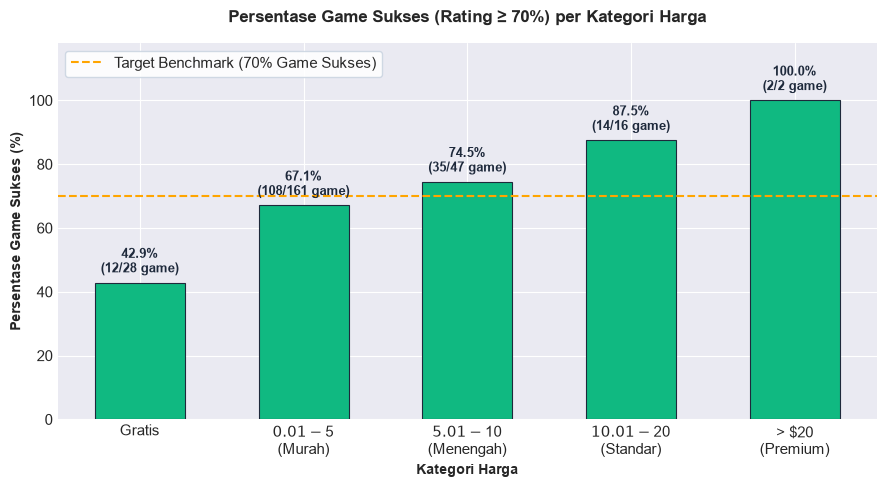

Tingkat Kesuksesan:
 - Gratis: 42.9% game sukses (12 dari 28 game)
 - $0.01 - $5 (Murah): 67.1% game sukses (108 dari 161 game)
 - $5.01 - $10 (Menengah): 74.5% game sukses (35 dari 47 game)
 - $10.01 - $20 (Standar): 87.5% game sukses (14 dari 16 game)
 - > $20 (Premium): 100.0% game sukses (2 dari 2 game)


In [15]:
# Persentase Game Sukses (Rating >= 70%) per Kategori Harga
df_reviewed = df_sample[df_sample['Total_Reviews'] >= 10].copy()
df_reviewed['Kategori_Harga'] = df_reviewed['Price_USD'].apply(tentukan_kategori)
urutan = ['Gratis', '$0.01 - $5\n(Murah)', '$5.01 - $10\n(Menengah)', '$10.01 - $20\n(Standar)', '> $20\n(Premium)']

# Hitung persentase game sukses dan totalnya
stats_sukses = df_reviewed.groupby('Kategori_Harga', observed=False).agg(
    Total=('Pct_Positive', 'count'),
    Sukses=('Pct_Positive', lambda x: (x >= 70).sum()),
    Persen=('Pct_Positive', lambda x: (x >= 70).mean() * 100)
).reindex(urutan)

plt.figure(figsize=(9, 5))
bars = plt.bar(stats_sukses.index, stats_sukses['Persen'], color='#10b981', width=0.55, edgecolor='#1e293b', linewidth=0.8)
plt.axhline(y=70, color='orange', linestyle='--', linewidth=1.5, label='Target Benchmark (70% Game Sukses)')
plt.title('Persentase Game Sukses (Rating ≥ 70%) per Kategori Harga', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kategori Harga', fontsize=10, fontweight='bold')
plt.ylabel('Persentase Game Sukses (%)', fontsize=10, fontweight='bold')
plt.ylim(0, 118)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cbd5e1')

# Tampilkan angka dan rasio game di atas setiap batang
for bar, total, sukses in zip(bars, stats_sukses['Total'], stats_sukses['Sukses']):
    val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%\n({sukses}/{total} game)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1e293b')

plt.tight_layout()
plt.savefig('eda_02b_boxplot_price_review.png', dpi=150, bbox_inches='tight')
plt.show()

print('Tingkat Kesuksesan:')
for kat, row in stats_sukses.iterrows():
    kat_clean = kat.replace('\n', ' ')
    print(f' - {kat_clean}: {row["Persen"]:.1f}% game sukses ({int(row["Sukses"])} dari {int(row["Total"])} game)')


### 5.3 Game Bermasalah: Harga Tinggi, Rating Rendah (Pertanyaan 3)

GAME BERMASALAH: Harga >  & Review Positif < 70%
        Name Genre_Utama  Price_USD  Pct_Positive  Total_Reviews
Rise of Ages      Action      16.99         44.76            210
 Ventura Inc       Indie      18.99         69.23             13

Total: 2 game bermasalah


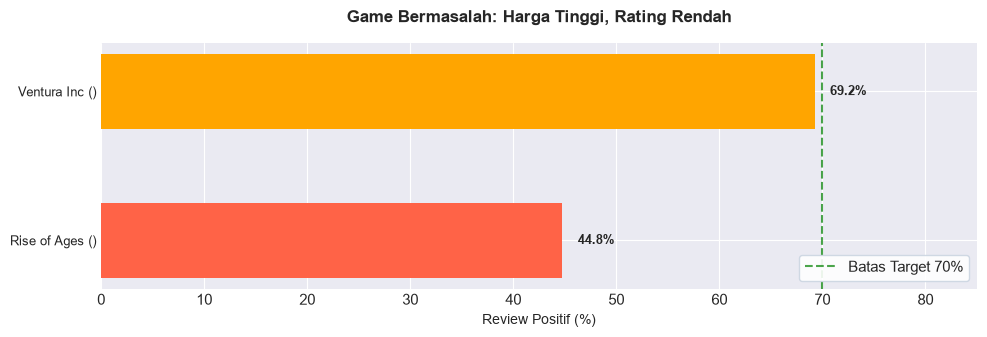

In [16]:
# Game Bermasalah: Harga Tinggi, Rating Rendah
df_problem = df_sample[
    (df_sample['Price_USD'] > 10) &
    (df_sample['Pct_Positive'] < 70) &
    (df_sample['Total_Reviews'] >= 10)
].sort_values('Pct_Positive')

print('=' * 60)
print('GAME BERMASALAH: Harga >  & Review Positif < 70%')
print('=' * 60)

if len(df_problem) > 0:
    print(df_problem[['Name', 'Genre_Utama', 'Price_USD', 'Pct_Positive', 'Total_Reviews']].to_string(index=False))
    print(f'\nTotal: {len(df_problem)} game bermasalah')

    plt.figure(figsize=(10, max(3.5, len(df_problem) * 0.8)))
    colors = ['tomato' if pct < 50 else 'orange' for pct in df_problem['Pct_Positive']]
    plt.barh(range(len(df_problem)), df_problem['Pct_Positive'], color=colors, height=0.5)
    plt.yticks(range(len(df_problem)),
               [f'{n[:30]} ()' for n, p in zip(df_problem['Name'], df_problem['Price_USD'])],
               fontsize=9)
    plt.xlabel('Review Positif (%)', fontsize=10)
    plt.title('Game Bermasalah: Harga Tinggi, Rating Rendah', fontsize=12, fontweight='bold', pad=15)
    plt.axvline(x=70, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Batas Target 70%')
    plt.xlim(0, 85)
    for idx, val in enumerate(df_problem['Pct_Positive']):
        plt.text(val + 1.5, idx, f'{val:.1f}%', va='center', ha='left', fontsize=9, fontweight='bold')
    plt.legend(loc='lower right', frameon=True, framealpha=0.9, facecolor='white', edgecolor='#cbd5e1')
    plt.tight_layout()
    plt.savefig('eda_03_problem_games.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Tidak ada game yang memenuhi kriteria di sample ini.')

### 5.4 Pola Waktu Rilis (Pertanyaan 4: Kapan Masalah Terjadi)

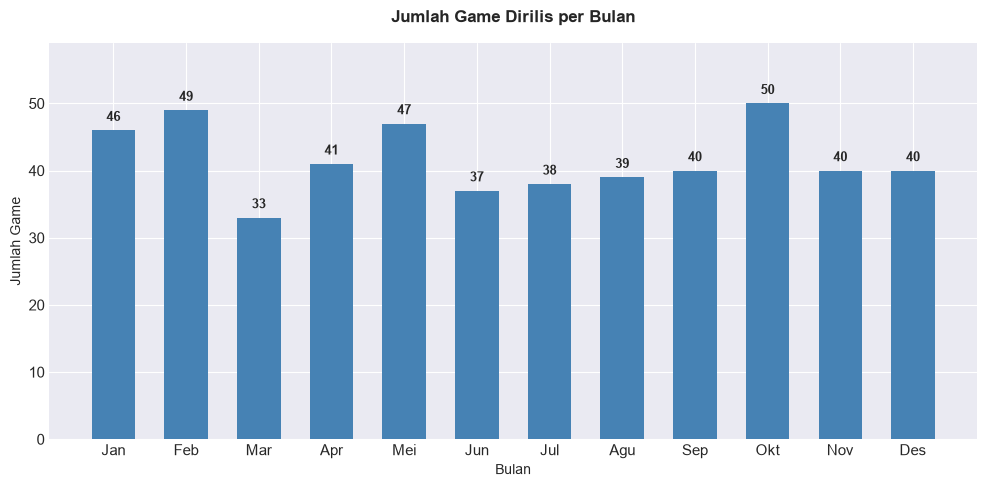

Bulan rilis terbanyak: Okt (50 game)


In [17]:
# Jumlah Game Dirilis per Bulan
monthly = df_sample.groupby('Bulan_Rilis').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
monthly = monthly.reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(10, 5))
plt.bar(month_names, monthly.values, color='steelblue', width=0.6)
plt.title('Jumlah Game Dirilis per Bulan', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Jumlah Game', fontsize=10)
plt.xlabel('Bulan', fontsize=10)
plt.ylim(0, max(monthly.values) * 1.18)
for idx, val in enumerate(monthly.values):
    plt.text(idx, val + 1, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04a_monthly_count.png', dpi=150, bbox_inches='tight')
plt.show()

peak_month = monthly.idxmax()
print(f'Bulan rilis terbanyak: {month_names[peak_month-1]} ({monthly[peak_month]} game)')

### 5.4b Rata-rata Review Positif per Bulan Rilis

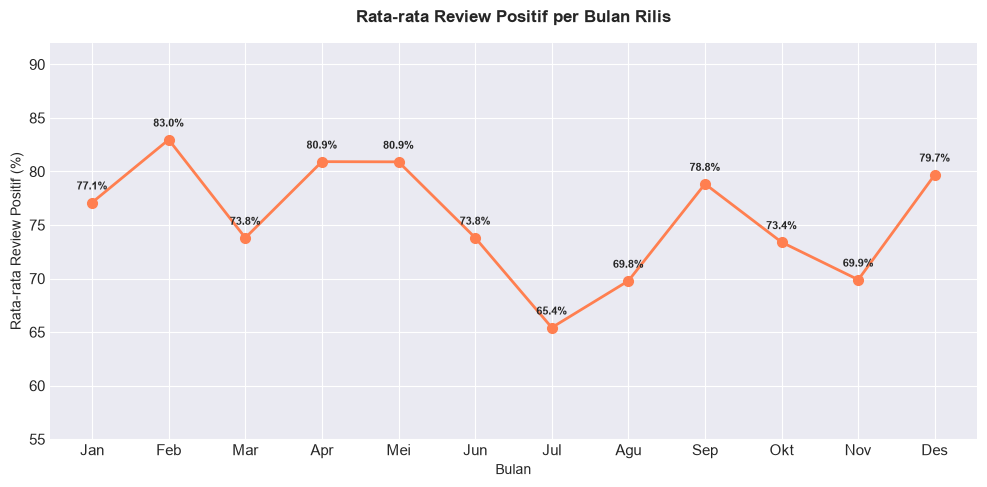

In [18]:
# Rata-rata Review Positif per Bulan Rilis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
monthly_pct = df_sample[df_sample['Total_Reviews'] >= 10].groupby('Bulan_Rilis')['Pct_Positive'].mean()
monthly_pct = monthly_pct.reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(10, 5))
plt.plot(month_names, monthly_pct.values, 'o-', color='coral', linewidth=2, markersize=7)
plt.title('Rata-rata Review Positif per Bulan Rilis', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Rata-rata Review Positif (%)', fontsize=10)
plt.xlabel('Bulan', fontsize=10)
plt.ylim(55, 92)
for idx, val in enumerate(monthly_pct.values):
    plt.text(idx, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04b_monthly_review.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Distribusi Harga Game

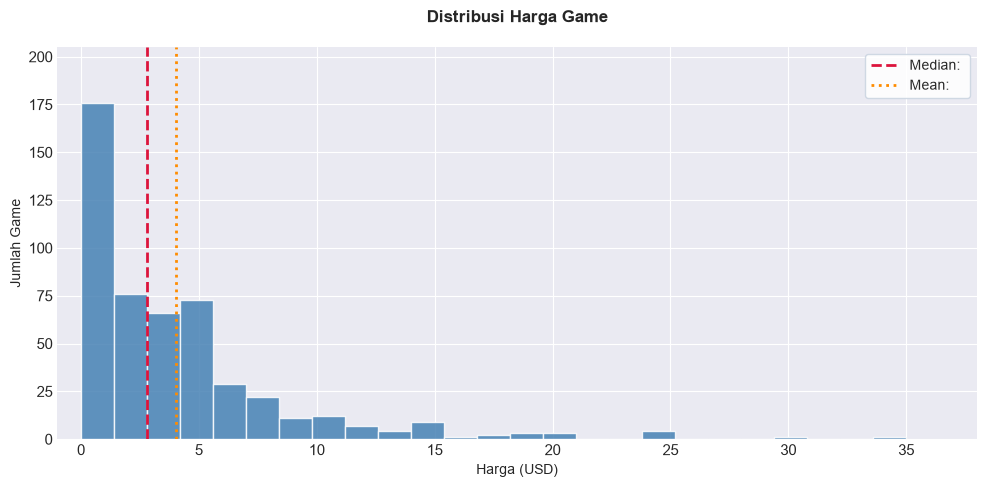

In [19]:
# Distribusi Harga Game
plt.figure(figsize=(10, 5))
plt.hist(df_sample['Price_USD'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Distribusi Harga Game', fontsize=12, fontweight='bold', pad=18)
plt.xlabel('Harga (USD)', fontsize=10)
plt.ylabel('Jumlah Game', fontsize=10)
med = df_sample['Price_USD'].median()
avg = df_sample['Price_USD'].mean()
plt.axvline(med, color='crimson', linestyle='--', linewidth=2, label=f'Median: ')
plt.axvline(avg, color='darkorange', linestyle=':', linewidth=2, label=f'Mean: ')
plt.xlim(-1, 38)
plt.ylim(0, 205)
plt.legend(loc='upper right', frameon=True, framealpha=0.9, facecolor='white', edgecolor='#cbd5e1', fontsize=10)
plt.tight_layout()
plt.savefig('eda_05a_price_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5b Proporsi Game Free vs Paid

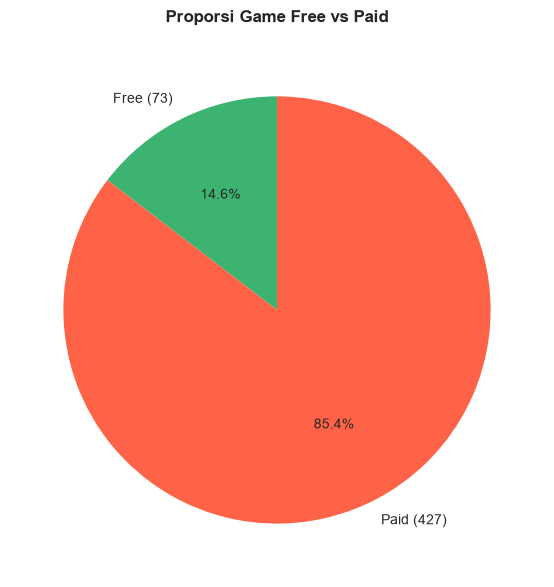

In [20]:
# Proporsi Game Free vs Paid
free_count = (df_sample['Price_USD'] == 0).sum()
paid_count = (df_sample['Price_USD'] > 0).sum()

plt.figure(figsize=(6, 6))
plt.pie([free_count, paid_count],
        labels=[f'Free ({free_count})', f'Paid ({paid_count})'],
        colors=['mediumseagreen', 'tomato'],
        autopct='%1.1f%%', pctdistance=0.6,
        startangle=90, textprops={'fontsize': 10})
plt.title('Proporsi Game Free vs Paid', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_05b_free_vs_paid.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Korelasi Antar Variabel Numerik

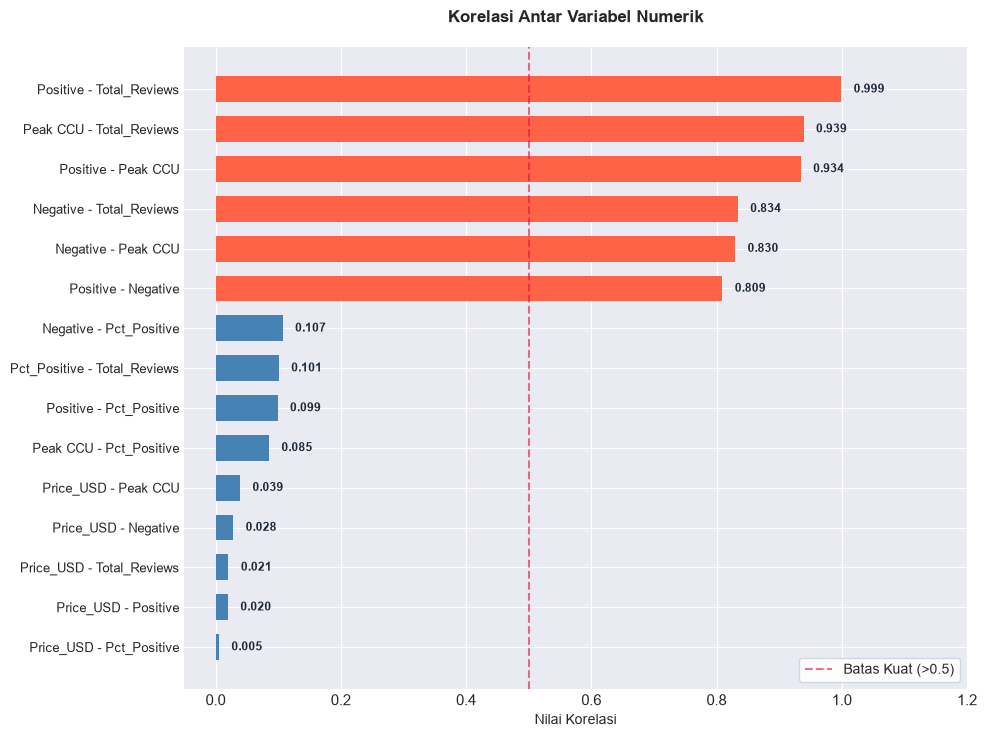

Top 3 Korelasi Tertinggi:
   Positive - Total_Reviews: 0.9991
   Peak CCU - Total_Reviews: 0.9389
   Positive - Peak CCU: 0.9344


In [21]:
# Korelasi Antar Variabel Numerik
numeric_cols = ['Price_USD', 'Positive', 'Negative', 'Peak CCU', 'Pct_Positive', 'Total_Reviews']
corr_matrix = df_sample[numeric_cols].corr()

# Ambil pasangan korelasi unik
pairs = []
for i_c in range(len(numeric_cols)):
    for j_c in range(i_c + 1, len(numeric_cols)):
        pairs.append((f'{numeric_cols[i_c]} - {numeric_cols[j_c]}', corr_matrix.iloc[i_c, j_c]))
pairs.sort(key=lambda x: abs(x[1]), reverse=True)

labels = [p[0] for p in pairs]
values = [p[1] for p in pairs]
colors = ['tomato' if v > 0.5 else 'steelblue' for v in values]

plt.figure(figsize=(10, 7.5))
plt.barh(range(len(labels)), values, color=colors, height=0.65)
plt.yticks(range(len(labels)), labels, fontsize=9)
plt.xlabel('Nilai Korelasi', fontsize=10)
plt.title('Korelasi Antar Variabel Numerik', fontsize=12, fontweight='bold', pad=18)
plt.axvline(x=0.5, color='crimson', linestyle='--', linewidth=1.5, alpha=0.6, label='Batas Kuat (>0.5)')
plt.xlim(-0.05, 1.20)
plt.legend(loc='lower right', frameon=True, framealpha=0.9, facecolor='white', edgecolor='#cbd5e1', fontsize=10)
for idx, val in enumerate(values):
    plt.text(val + 0.02, idx, f'{val:.3f}', va='center', ha='left', fontsize=8.5, fontweight='bold', color='#1e293b')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('eda_06_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 Korelasi Tertinggi:')
for label, val in pairs[:3]:
    print(f'   {label}: {val:.4f}')

---
## Langkah 6: Insight & Rekomendasi

### Format Wajib: "Berdasarkan data, ... sehingga keputusan yang disarankan adalah ..."

In [22]:
# ============================================
# INSIGHT 1: Pola Utama Genre
# ============================================
top_genre = df_sample['Genre_Utama'].value_counts().index[0]
top_genre_count = df_sample['Genre_Utama'].value_counts().values[0]
top_genre_pct = (top_genre_count / len(df_sample) * 100)

print('=' * 70)
print('INSIGHT 1: Pola Utama Genre')
print('=' * 70)
print(f'\nTemuan: Genre "{top_genre}" mendominasi dataset dengan {top_genre_count} game ({top_genre_pct:.1f}%).')
print(f'\nInterpretasi: Pasar game Steam didominasi oleh genre tertentu,')
print(f'menunjukkan kompetisi yang sangat ketat di genre tersebut.')
print(f'\nBerdasarkan data, genre "{top_genre}" memiliki jumlah game terbanyak')
print(f'({top_genre_count} game, {top_genre_pct:.1f}% dari total), sehingga keputusan yang')
print(f'disarankan adalah developer indie sebaiknya mempertimbangkan niche')
print(f'genre yang lebih spesifik untuk mengurangi persaingan langsung.')

INSIGHT 1: Pola Utama Genre

Temuan: Genre "Action" mendominasi dataset dengan 194 game (38.8%).

Interpretasi: Pasar game Steam didominasi oleh genre tertentu,
menunjukkan kompetisi yang sangat ketat di genre tersebut.

Berdasarkan data, genre "Action" memiliki jumlah game terbanyak
(194 game, 38.8% dari total), sehingga keputusan yang
disarankan adalah developer indie sebaiknya mempertimbangkan niche
genre yang lebih spesifik untuk mengurangi persaingan langsung.


In [23]:
# ============================================
# INSIGHT 2: Hubungan Harga dan Review
# ============================================
df_rev = df_sample[df_sample['Total_Reviews'] >= 10]
corr_price_review = df_rev['Price_USD'].corr(df_rev['Pct_Positive'])

# Rata-rata review per kategori harga
free_avg = df_rev[df_rev['Price_USD'] == 0]['Pct_Positive'].mean()
cheap_avg = df_rev[(df_rev['Price_USD'] > 0) & (df_rev['Price_USD'] <= 10)]['Pct_Positive'].mean()
expensive_avg = df_rev[df_rev['Price_USD'] > 10]['Pct_Positive'].mean()

print('=' * 70)
print('INSIGHT 2: Hubungan Harga dan Review')
print('=' * 70)
print(f'\nTemuan:')
print(f'   Korelasi harga vs review positif: {corr_price_review:.4f}')
print(f'   Rata-rata review positif game Free    : {free_avg:.1f}%')
print(f'   Rata-rata review positif game $0-10   : {cheap_avg:.1f}%')
print(f'   Rata-rata review positif game >$10    : {expensive_avg:.1f}%')

strength = 'lemah' if abs(corr_price_review) < 0.3 else ('sedang' if abs(corr_price_review) < 0.7 else 'kuat')
print(f'\nBerdasarkan data, korelasi antara harga dan persentase review positif')
print(f'adalah {corr_price_review:.4f} ({strength}),')
print(f'sehingga keputusan yang disarankan adalah developer tidak perlu')
print(f'menetapkan harga murah demi review bagus, tetapi fokus pada kualitas game.')

INSIGHT 2: Hubungan Harga dan Review

Temuan:
   Korelasi harga vs review positif: 0.1098
   Rata-rata review positif game Free    : 67.5%
   Rata-rata review positif game $0-10   : 76.5%
   Rata-rata review positif game >$10    : 80.1%

Berdasarkan data, korelasi antara harga dan persentase review positif
adalah 0.1098 (lemah),
sehingga keputusan yang disarankan adalah developer tidak perlu
menetapkan harga murah demi review bagus, tetapi fokus pada kualitas game.


In [24]:
# ============================================
# INSIGHT 3: Game Bermasalah
# ============================================
df_problem = df_sample[
    (df_sample['Price_USD'] > 10) &
    (df_sample['Pct_Positive'] < 70) &
    (df_sample['Total_Reviews'] >= 10)
]

print('=' * 70)
print('INSIGHT 3: Game Bermasalah (Harga Tinggi, Rating Rendah)')
print('=' * 70)
print(f'\nTemuan: Terdapat {len(df_problem)} game dengan harga > $10')
print(f'yang mendapat review positif di bawah 70%.')

if len(df_problem) > 0:
    problem_genres = df_problem['Genre_Utama'].value_counts()
    print(f'Genre yang paling bermasalah: {problem_genres.index[0]} ({problem_genres.values[0]} game)')

print(f'\nBerdasarkan data, {len(df_problem)} game dengan harga di atas $10 mendapat')
print(f'review positif di bawah 70%, sehingga keputusan yang disarankan adalah')
print(f'developer harus melakukan playtesting intensif sebelum menetapkan harga')
print(f'premium untuk menghindari review negatif yang merugikan penjualan.')

INSIGHT 3: Game Bermasalah (Harga Tinggi, Rating Rendah)

Temuan: Terdapat 2 game dengan harga > $10
yang mendapat review positif di bawah 70%.
Genre yang paling bermasalah: Indie (1 game)

Berdasarkan data, 2 game dengan harga di atas $10 mendapat
review positif di bawah 70%, sehingga keputusan yang disarankan adalah
developer harus melakukan playtesting intensif sebelum menetapkan harga
premium untuk menghindari review negatif yang merugikan penjualan.


In [25]:
# ============================================
# INSIGHT 4: Pola Waktu Rilis
# ============================================
monthly = df_sample.groupby('Bulan_Rilis').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
monthly = monthly.reindex(range(1, 13), fill_value=0)

peak = monthly.idxmax()
trough = monthly.idxmin()

print('=' * 70)
print('INSIGHT 4: Pola Waktu Rilis')
print('=' * 70)
print(f'\nTemuan:')
print(f'   Bulan rilis terbanyak : {month_names[peak-1]} ({monthly[peak]} game)')
print(f'   Bulan rilis tersedikit: {month_names[trough-1]} ({monthly[trough]} game)')
print(f'\nBerdasarkan data, bulan {month_names[peak-1]} memiliki jumlah rilis terbanyak')
print(f'({monthly[peak]} game), sehingga keputusan yang disarankan adalah developer')
print(f'indie sebaiknya menghindari rilis di bulan tersebut dan memilih bulan')
print(f'{month_names[trough-1]} yang kompetisinya lebih rendah.')

INSIGHT 4: Pola Waktu Rilis

Temuan:
   Bulan rilis terbanyak : Okt (50 game)
   Bulan rilis tersedikit: Mar (33 game)

Berdasarkan data, bulan Okt memiliki jumlah rilis terbanyak
(50 game), sehingga keputusan yang disarankan adalah developer
indie sebaiknya menghindari rilis di bulan tersebut dan memilih bulan
Mar yang kompetisinya lebih rendah.


In [26]:
# ============================================
# INSIGHT 5: Rekomendasi Strategi
# ============================================
df_viable = df_sample[
    (df_sample['Total_Reviews'] >= 10) &
    (df_sample['Pct_Positive'] >= 70)
]

if len(df_viable) > 0:
    best_genre = df_viable['Genre_Utama'].value_counts().index[0]
    best_genre_avg_price = df_viable[df_viable['Genre_Utama'] == best_genre]['Price_USD'].mean()
    best_genre_avg_review = df_viable[df_viable['Genre_Utama'] == best_genre]['Pct_Positive'].mean()
    best_genre_count = df_viable[df_viable['Genre_Utama'] == best_genre].shape[0]
else:
    best_genre = 'N/A'
    best_genre_avg_price = 0
    best_genre_avg_review = 0
    best_genre_count = 0

print('=' * 70)
print('INSIGHT 5: Rekomendasi Strategi untuk Developer Indie')
print('=' * 70)
print(f'\nTemuan: Genre "{best_genre}" memiliki {best_genre_count} game dengan')
print(f'rata-rata review positif {best_genre_avg_review:.1f}% dan harga rata-rata ${best_genre_avg_price:.2f}')
print(f'\nBerdasarkan data, game dengan genre "{best_genre}" di rentang harga')
print(f'sekitar ${best_genre_avg_price:.2f} memiliki rata-rata persentase ulasan positif')
print(f'{best_genre_avg_review:.1f}%, sehingga keputusan yang disarankan adalah developer')
print(f'baru sebaiknya memprioritaskan pengembangan game genre "{best_genre}"')
print(f'di rentang harga tersebut untuk meminimalisir risiko kerugian di rilis pertama.')
print(f'\nRINGKASAN REKOMENDASI:')
print(f'   1. Pilih genre niche, hindari pasar yang sudah terlalu jenuh')
print(f'   2. Kualitas > harga murah - fokus playtesting sebelum rilis')
print(f'   3. Hindari rilis di bulan puncak kompetisi')
print(f'   4. Targetkan review positif > 70% sebagai KPI utama')
print(f'   5. Manfaatkan model Free-to-Play jika budget terbatas')

INSIGHT 5: Rekomendasi Strategi untuk Developer Indie

Temuan: Genre "Action" memiliki 60 game dengan
rata-rata review positif 87.0% dan harga rata-rata $4.99

Berdasarkan data, game dengan genre "Action" di rentang harga
sekitar $4.99 memiliki rata-rata persentase ulasan positif
87.0%, sehingga keputusan yang disarankan adalah developer
baru sebaiknya memprioritaskan pengembangan game genre "Action"
di rentang harga tersebut untuk meminimalisir risiko kerugian di rilis pertama.

RINGKASAN REKOMENDASI:
   1. Pilih genre niche, hindari pasar yang sudah terlalu jenuh
   2. Kualitas > harga murah - fokus playtesting sebelum rilis
   3. Hindari rilis di bulan puncak kompetisi
   4. Targetkan review positif > 70% sebagai KPI utama
   5. Manfaatkan model Free-to-Play jika budget terbatas


---
## Ringkasan Proses

| Tahap | Deskripsi | Status |
|-------|-----------|--------|
| 1. Rumusan Masalah | 5 pertanyaan analitik tentang strategi game indie | Done |
| 2. Dataset | Steam Games - 500 sample dari dataset lengkap | Done |
| 3. Data Cleaning | Missing, Duplikat, Konsistensi, Outlier | Done |
| 4. Analisis 5V | Volume, Velocity, Variety, Veracity, Value | Done |
| 5. EDA | 6 visualisasi (distribusi, korelasi, tren, perbandingan) | Done |
| 6. Insight & Rekomendasi | 5 insight dengan format wajib dosen | Done |